In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df_raw = pd.read_csv("../data/raw/telco_customer_churn.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
def clean_data(df):
    """Same cleaning steps as in data_ingestion.py."""
    df = df.copy()
    # Convert TotalCharges to numeric, filling blanks with MonthlyCharges * tenure
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])
    # Drop customerID (not used)
    df = df.drop(columns=["customerID"])
    return df

df = clean_data(df_raw)
print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
CATEGORICAL_FEATURES = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]
TARGET = "Churn"

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET].map({"Yes": 1, "No": 0})

print("Features:", len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES))
print("Target distribution:\n", y.value_counts(normalize=True))

Features: 19
Target distribution:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Training set size: 5634
Test set size: 1409

Train target distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)

print("Cross-Validation Results (5-fold):")
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:12s} = {scores.mean():.4f} ± {scores.std():.4f}")

Cross-Validation Results (5-fold):
accuracy     = 0.7485 ± 0.0153
precision    = 0.5169 ± 0.0189
recall       = 0.8013 ± 0.0379
f1           = 0.6283 ± 0.0232
roc_auc      = 0.8460 ± 0.0124


In [9]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [10]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print("Test Set Performance:")
for k, v in metrics.items():
    print(f"{k:12s} = {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Test Set Performance:
accuracy     = 0.7381
precision    = 0.5043
recall       = 0.7834
f1           = 0.6136
roc_auc      = 0.8416

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



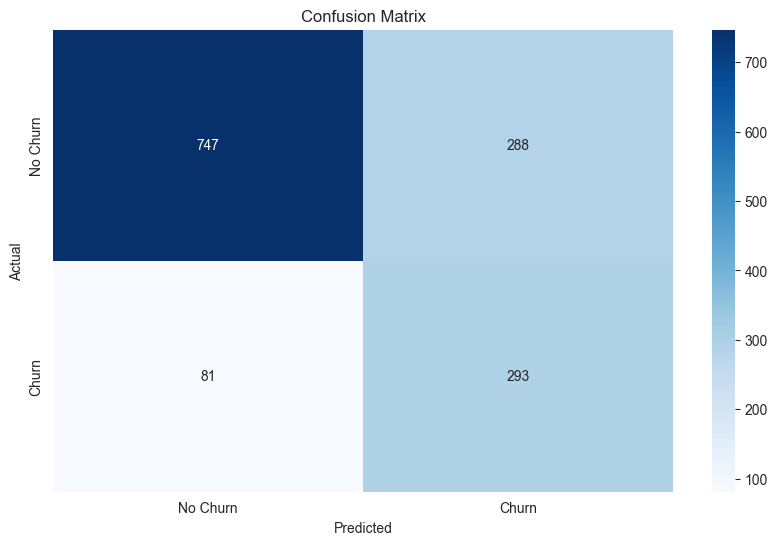

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Churn", "Churn"], 
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

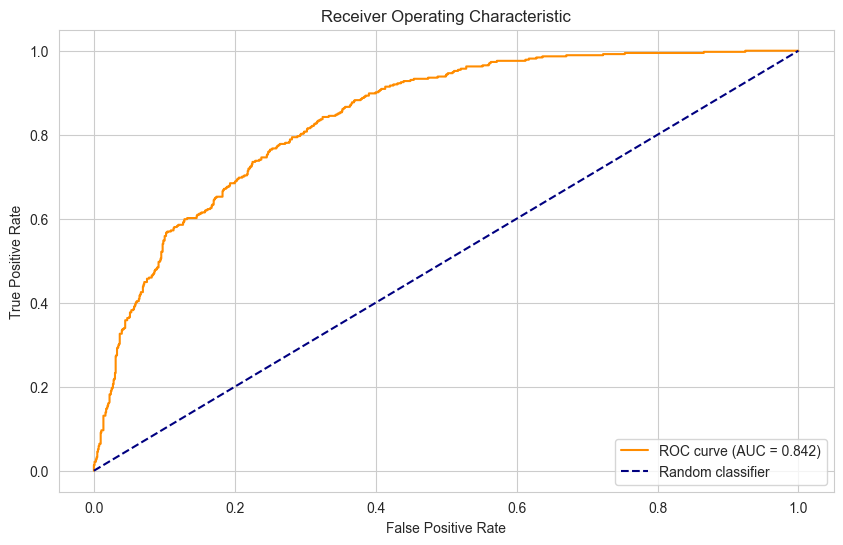

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="navy", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.show()

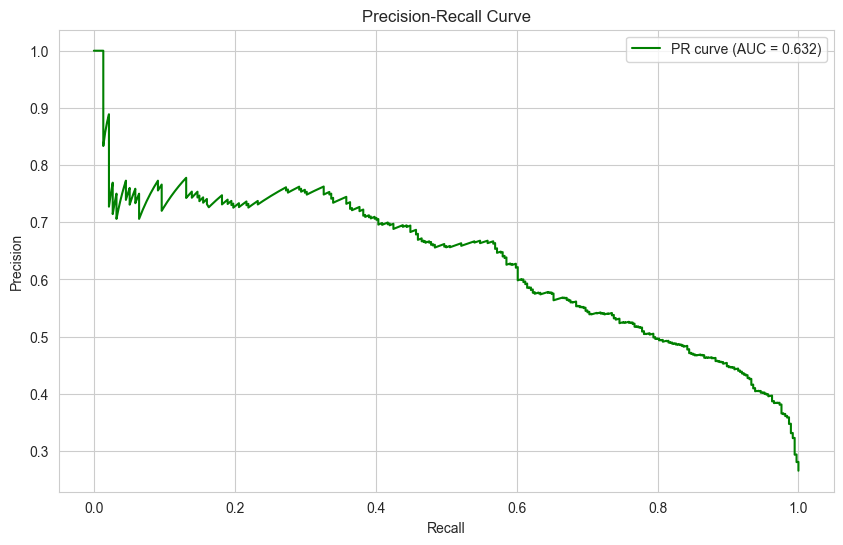

In [13]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})", color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.show()

In [14]:
# Get feature names after preprocessing
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = pipeline.named_steps["classifier"].coef_[0]

# Sort by absolute coefficient
importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print("Top 20 most influential features (by absolute coefficient):")
importance.head(20)[["feature", "coefficient"]]

Top 20 most influential features (by absolute coefficient):


,feature,coefficient
0,num__tenure,-1.154434
38,cat__Contract_Two year,-0.775518
16,cat__InternetService_Fiber optic,0.707981
1,num__MonthlyCharges,-0.676114
36,cat__Contract_Month-to-month,0.657713
15,cat__InternetService_DSL,-0.622465
2,num__TotalCharges,0.489698
28,cat__TechSupport_No internet service,-0.275403
25,cat__DeviceProtection_No internet service,-0.275403
17,cat__InternetService_No,-0.275403
